# Analisis kualitas udara Kota Makassar
Program ini menganalisis data kualitas udara daerah Kota Makassar.
Adapun bagian-bagian yang akan diproses sebagai berikut:
1. import library
2. Download dan baca data dari internet

In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
from sklearn.ensemble import AdaBoostRegressor 
from sklearn.ensemble import RandomForestRegressor 

## 1. Download dan Baca Data
Data polusi udara diunduh dari laman:  dan disimpan dalam bentuk csv. Data ini disimpan dalam directory data

In [18]:
#Data pertama, yakni data akibat polusi udara
polusi = pd.read_csv('data/polut_makassar.csv', delimiter=';')
polusi.head()

,Date,NO2,CO,O3,SO2,AQI(NO2),AQI(SO2)
0,2018-01-01,0,0.0,0.0,0,0,0
1,2018-01-15,0,0.0,0.0,0,0,0
2,2018-01-23,0,0.0,0.0,0,0,0
3,2018-02-14,0,0.0,0.0,0,0,0
4,2018-02-25,0,0.0,0.0,0,0,0


In [19]:
#Data pembantu dari dari korelasi polusi udara dengan perubahan cuaca
met = pd.read_csv('data/meteo_Makassar.csv', delimiter=';')
met.head()

,Year,Temp,Prep,WindSp
0,01/01/2018,27.08,0.90,2.84
1,02/01/2018,27.48,1.01,2.80
2,03/01/2018,27.70,0.99,1.99
3,04/01/2018,27.79,0.95,1.95
4,05/01/2018,27.08,5.54,2.92


In [20]:
polusi= polusi.iloc[:, : -2]

In [21]:
#Print 5 baris awal
polusi.head()

,Date,NO2,CO,O3,SO2
0,2018-01-01,0,0.0,0.0,0
1,2018-01-15,0,0.0,0.0,0
2,2018-01-23,0,0.0,0.0,0
3,2018-02-14,0,0.0,0.0,0
4,2018-02-25,0,0.0,0.0,0


In [22]:
#Print 5 baris terakhir
polusi.tail()

,Date,NO2,CO,O3,SO2
250,2024-03-20,0,0.0,0.111,0
251,2024-03-29,23,0.0,0.109,0
252,2024-04-07,16,0.0,0.109,0
253,2024-04-16,13,0.0,0.112,76
254,2024-04-25,18,0.0,0.112,0


In [23]:
polusi.shape

(255, 5)

In [24]:
polusi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    255 non-null    object 
 1   NO2     255 non-null    int64  
 2   CO      255 non-null    float64
 3   O3      255 non-null    float64
 4   SO2     255 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 10.1+ KB


In [25]:
#Cek untuk nomor yang hialng dari dataframe
polusi.isnull().sum()

Date    0
NO2     0
CO      0
O3      0
SO2     0
dtype: int64

In [26]:
polusi.isin([20]).sum(axis=0)

Date     0
NO2     24
CO       0
O3       0
SO2      1
dtype: int64

In [27]:
#Untuk mengubah data mines menjadi angka nol karena tidak ada data polusi dengan angka yang mines
polusi=polusi.replace(to_replace=-46.652, value=np.nan)

In [28]:
polusi.isnull().sum()

Date    0
NO2     0
CO      0
O3      0
SO2     0
dtype: int64

In [29]:
polusi.head()

,Date,NO2,CO,O3,SO2
0,2018-01-01,0,0.0,0.0,0
1,2018-01-15,0,0.0,0.0,0
2,2018-01-23,0,0.0,0.0,0
3,2018-02-14,0,0.0,0.0,0
4,2018-02-25,0,0.0,0.0,0


In [30]:
polusi=polusi.fillna(polusi.mean)

In [31]:
DATA_INFO= pd.to_datetime(polusi['Date'])
print(DATA_INFO)

0     2018-01-01
1     2018-01-15
2     2018-01-23
3     2018-02-14
4     2018-02-25
         ...    
250   2024-03-20
251   2024-03-29
252   2024-04-07
253   2024-04-16
254   2024-04-25
Name: Date, Length: 255, dtype: datetime64[ns]


In [32]:
print(type(DATA_INFO))

<class 'pandas.core.series.Series'>


In [33]:
date_time=pd.concat([DATA_INFO], axis=1)

In [34]:
data= pd.DataFrame()

In [35]:
data['Date']=pd.to_datetime(date_time['Date'])

In [36]:
data.head()

,Date
0,2018-01-01
1,2018-01-15
2,2018-01-23
3,2018-02-14
4,2018-02-25


In [37]:
polutan = ['NO2', 'CO', 'O3', 'SO2']

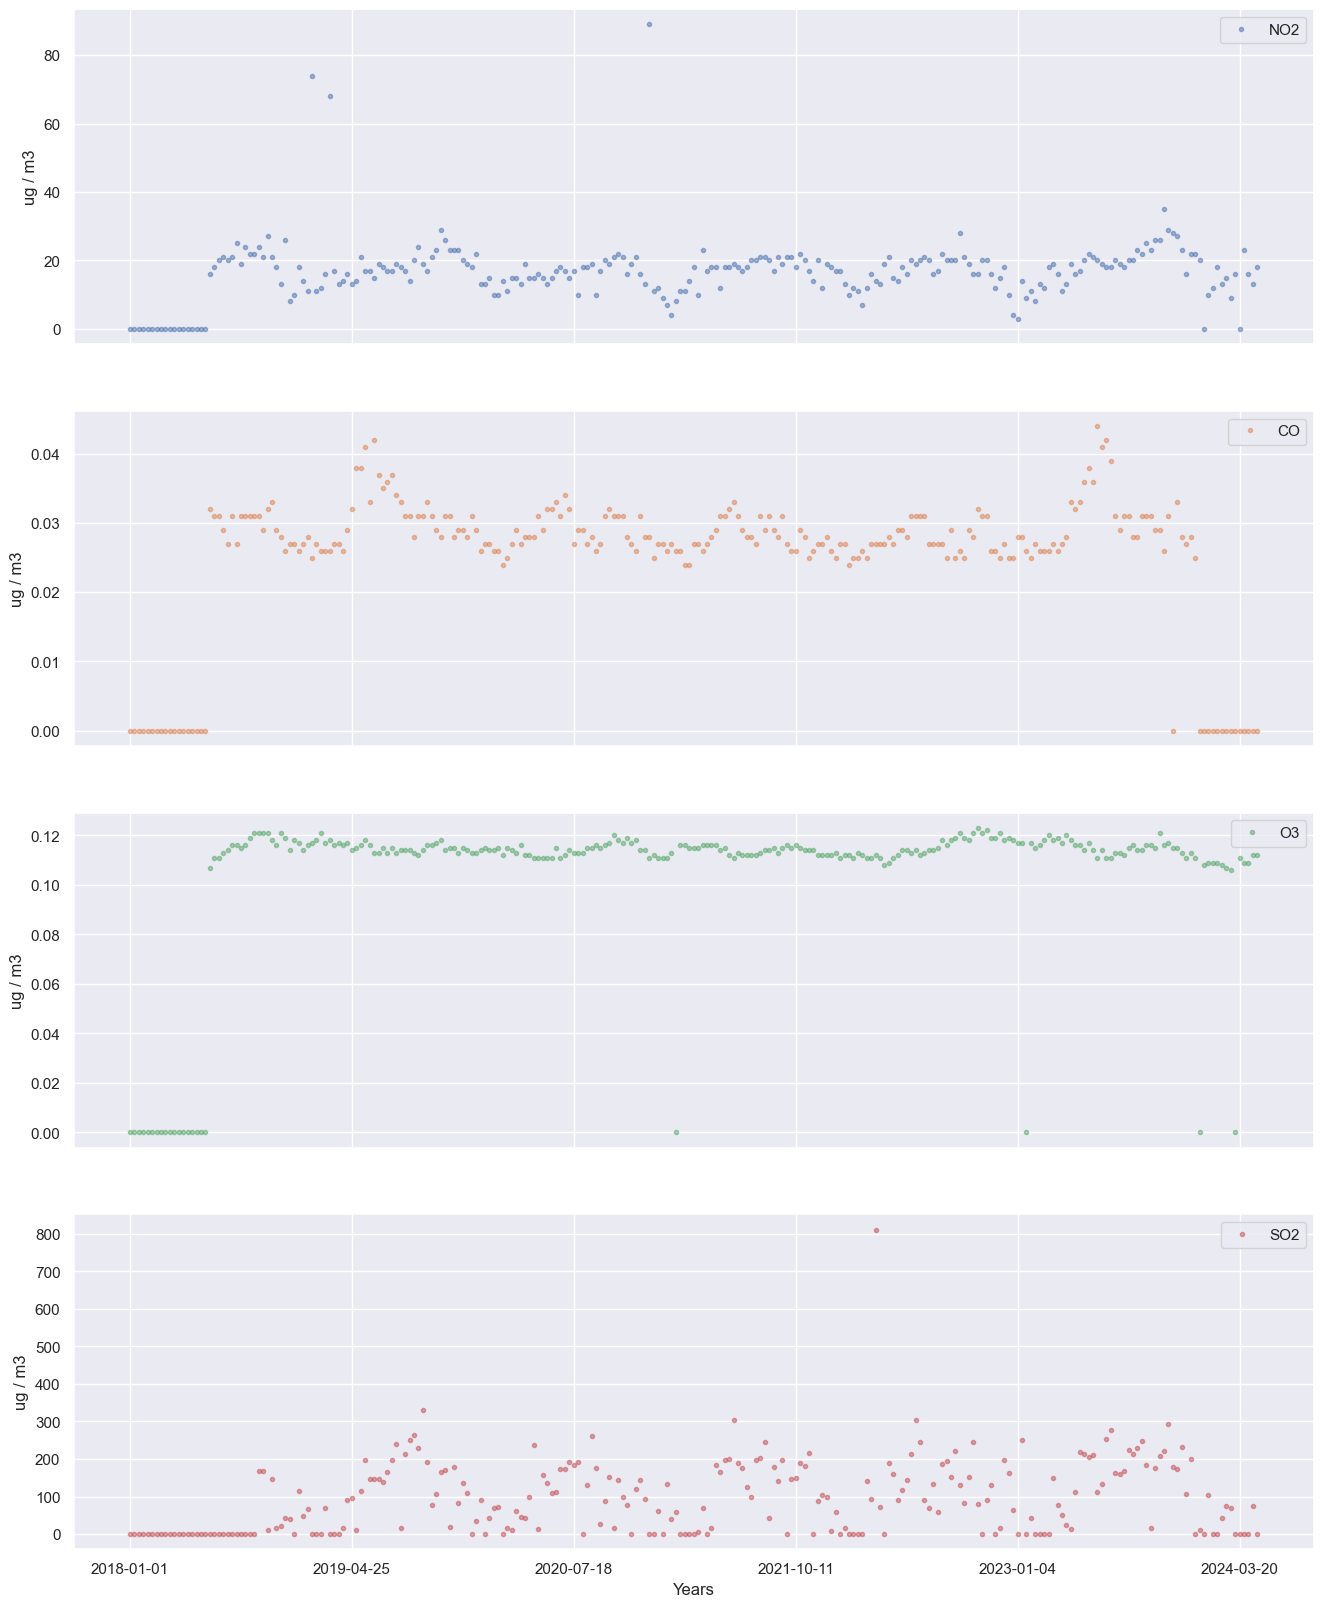

In [38]:
polusi.set_index('Date',inplace=True)
axes = polusi[polutan].plot(marker='.', alpha=0.5, linestyle='None', figsize=(16, 20), subplots=True)
for ax in axes:
    
    ax.set_xlabel('Years')
    ax.set_ylabel('ug / m3')

In [39]:
def trend_plot(dataframe,value):
    
    # Prepare data
    polusi['year'] = [d.year for d in polusi.Date]
    polusi['month'] = [d.strftime('%b') for d in polusi.Date]
    years = polusi['year'].unique()

    # Draw Plot
    fig, axes = plt.subplots(1, 2, figsize=(14,6), dpi= 80)
    sns.boxplot(x='year', y=value, data=polusi, ax=axes[0])
    sns.pointplot(x='month', y=value, data=df.loc[polusi.year.isin([2015, 2020]), :])

    # Set Title
    axes[0].set_title('Year-wise Box Plot \n(The Trend)', fontsize=18); 
    axes[1].set_title('Month-wise Plot \n(The Seasonality)', fontsize=18)
    plt.show()

In [40]:
polusi.reset_index(inplace=True)
df = polusi.copy()
value='NO2'
trend_plot(df,value)

AttributeError: 'str' object has no attribute 'year'

In [41]:
date_time ['ds'] = date_time['Date'].astype(str)

In [42]:
data['ds'] = pd.to_datetime(date_time['ds'])

In [43]:
data.head()

,Date,ds
0,2018-01-01,2018-01-01
1,2018-01-15,2018-01-15
2,2018-01-23,2018-01-23
3,2018-02-14,2018-02-14
4,2018-02-25,2018-02-25


In [44]:
data['y']=polusi['NO2']

In [45]:
data.head()

,Date,ds,y
0,2018-01-01,2018-01-01,0
1,2018-01-15,2018-01-15,0
2,2018-01-23,2018-01-23,0
3,2018-02-14,2018-02-14,0
4,2018-02-25,2018-02-25,0


In [47]:
from prophet import Prophet
model = Prophet()
model.fit(data)

21:29:56 - cmdstanpy - INFO - Chain [1] start processing
21:29:56 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
future = model.make_future_dataframe(periods=365, freq='h')
future.tail()

,ds
614,2024-05-10 01:00:00
615,2024-05-10 02:00:00
616,2024-05-10 03:00:00
617,2024-05-10 04:00:00
618,2024-05-10 05:00:00


In [49]:
forecast = model.predict(future)
forecast [['ds', 'yhat','yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
614,2024-05-10 01:00:00,17.298658,6.492345,27.012280
615,2024-05-10 02:00:00,17.217355,6.547821,27.129063
616,2024-05-10 03:00:00,17.117589,7.250367,27.021394
617,2024-05-10 04:00:00,17.000482,7.052870,28.185667
618,2024-05-10 05:00:00,16.867334,6.156921,27.217125


c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



Text(0.5, 0.98, 'NO2')

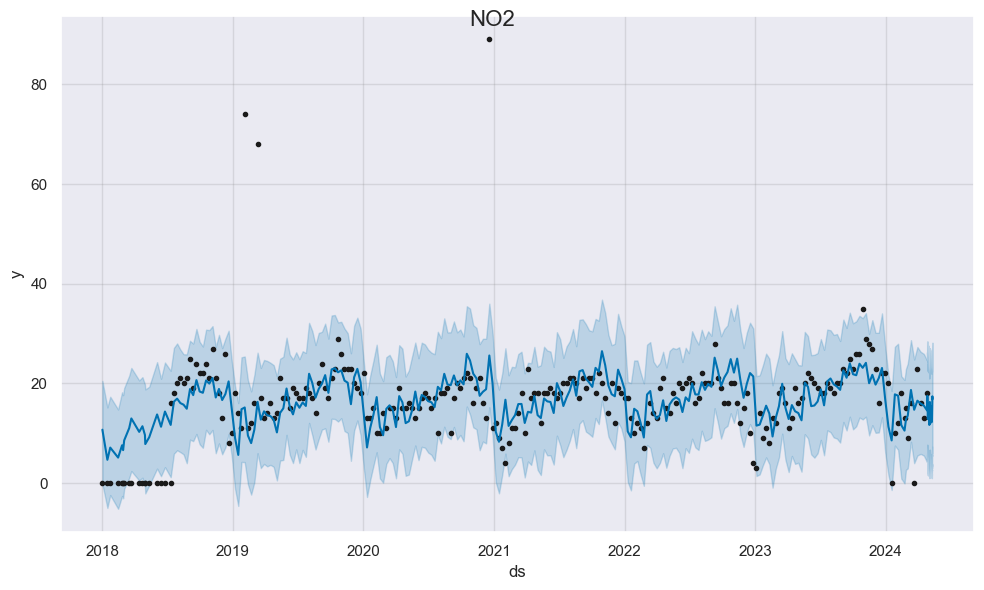

In [65]:
fig1 = model.plot(forecast)
fig1.suptitle('NO2', fontsize=16)

c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



Text(0.5, 0.98, 'NO2')

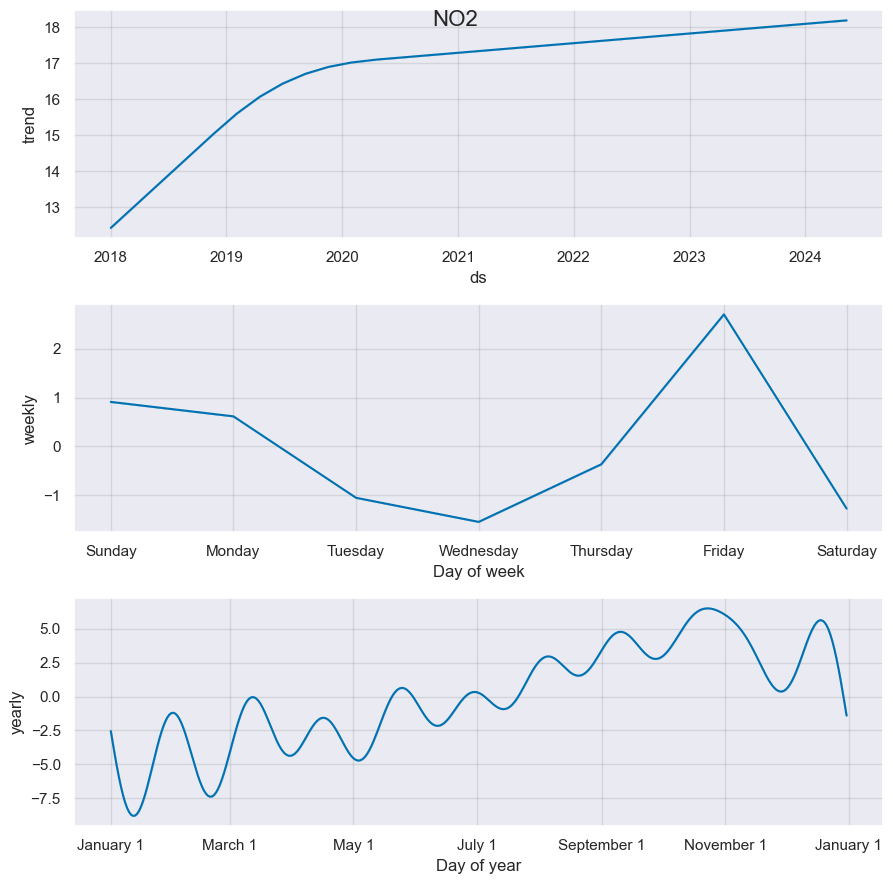

In [64]:
fig2 = model.plot_components(forecast)
fig2.suptitle('NO2', fontsize=16)



In [52]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(model, forecast)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': 'black', 'size': 4},
              'mode': 'markers',
              'name': 'Actual',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 1, 1, 0, 0),
                          datetime.datetime(2018, 1, 15, 0, 0),
                          datetime.datetime(2018, 1, 23, 0, 0), ...,
                          datetime.datetime(2024, 4, 7, 0, 0),
                          datetime.datetime(2024, 4, 16, 0, 0),
                          datetime.datetime(2024, 4, 25, 0, 0)], dtype=object),
              'y': array([ 0,  0,  0, ..., 16, 13, 18], dtype=int64)},
             {'hoverinfo': 'skip',
              'line': {'width': 0},
              'mode': 'lines',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 1, 1, 0, 0),
                          datetime.datetime(2018, 1, 15, 0, 0),
                          datetime.datetime(2018, 1, 23, 0, 0), ...,
                          datetime.datetime(2024, 5, 10, 3, 0),
                          datetime.datetime(2024, 5, 10, 4, 0),
                          datetime.datetime(2024, 5, 10, 5, 0)], dtype=object),
              'y': array([-0.16426624, -4.96632519, -2.38324302, ...,  7.25036731,  7.05286984,
                           6.15692057])},
             {'fill': 'tonexty',
              'fillcolor': 'rgba(0, 114, 178, 0.2)',
              'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'Predicted',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 1, 1, 0, 0),
                          datetime.datetime(2018, 1, 15, 0, 0),
                          datetime.datetime(2018, 1, 23, 0, 0), ...,
                          datetime.datetime(2024, 5, 10, 3, 0),
                          datetime.datetime(2024, 5, 10, 4, 0),
                          datetime.datetime(2024, 5, 10, 5, 0)], dtype=object),
              'y': array([10.7302918 ,  4.68796056,  7.14104688, ..., 17.11758875, 17.00048164,
                          16.86733369])},
             {'fill': 'tonexty',
              'fillcolor': 'rgba(0, 114, 178, 0.2)',
              'hoverinfo': 'skip',
              'line': {'width': 0},
              'mode': 'lines',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 1, 1, 0, 0),
                          datetime.datetime(2018, 1, 15, 0, 0),
                          datetime.datetime(2018, 1, 23, 0, 0), ...,
                          datetime.datetime(2024, 5, 10, 3, 0),
                          datetime.datetime(2024, 5, 10, 4, 0),
                          datetime.datetime(2024, 5, 10, 5, 0)], dtype=object),
              'y': array([20.51898774, 15.19921941, 17.34010916, ..., 27.02139391, 28.18566683,
                          27.21712496])}],
    'layout': {'height': 600,
               'showlegend': False,
               'template': '...',
               'width': 900,
               'xaxis': {'rangeselector': {'buttons': [{'count': 7, 'label': '1w', 'step': 'day', 'stepmode': 'backward'},
                                                       {'count': 1,
                                                        'label': '1m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 6,
                                                        'label': '6m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 1, 'label': '1y', 'step': 'year', 'stepmode': 'backward'},
                                                       {'step': 'all'}]},
                         'rangeslider': {'visible': True},
                         'title': {'text': 'd

In [59]:
plot_components_plotly(model, forecast)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'trend',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 1, 1, 0, 0),
                          datetime.datetime(2018, 1, 15, 0, 0),
                          datetime.datetime(2018, 1, 23, 0, 0), ...,
                          datetime.datetime(2024, 5, 10, 3, 0),
                          datetime.datetime(2024, 5, 10, 4, 0),
                          datetime.datetime(2024, 5, 10, 5, 0)], dtype=object),
              'xaxis': 'x',
              'y': array([12.43241   , 12.54529728, 12.60980429, ..., 18.19275762, 18.19278819,
                          18.19281876]),
              'yaxis': 'y'},
             {'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'yearly',
              'type': 'scatter',
              'x': array([datetime.datetime(2017, 1, 1, 0, 0),
                          datetime.datetime(2017, 1, 2, 0, 0, 59, 178082),
                          datetime.datetime(2017, 1, 3, 0, 1, 58, 356164), ...,
                          datetime.datetime(2017, 12, 29, 5, 57, 2, 465753),
                          datetime.datetime(2017, 12, 30, 5, 58, 1, 643835),
                          datetime.datetime(2017, 12, 31, 5, 59, 0, 821917)], dtype=object),
              'xaxis': 'x2',
              'y': array([-2.54591106, -3.44970813, -4.32454739, ...,  0.18255993, -0.71417686,
                          -1.62881381]),
              'yaxis': 'y2'},
             {'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'weekly',
              'type': 'scatter',
              'x': array([datetime.datetime(2017, 1, 1, 0, 0),
                          datetime.datetime(2017, 1, 2, 0, 0),
                          datetime.datetime(2017, 1, 3, 0, 0),
                          datetime.datetime(2017, 1, 4, 0, 0),
                          datetime.datetime(2017, 1, 5, 0, 0),
                          datetime.datetime(2017, 1, 6, 0, 0),
                          datetime.datetime(2017, 1, 7, 0, 0)], dtype=object),
              'xaxis': 'x3',
              'y': array([ 0.91077869,  0.61530697, -1.05008422, -1.54251312, -0.36469708,
                           2.70048999, -1.26928123]),
              'yaxis': 'y3'}],
    'layout': {'height': 600,
               'showlegend': False,
               'template': '...',
               'width': 900,
               'xaxis': {'anchor': 'y',
                         'domain': [0.0, 1.0],
                         'range': [2017-09-06 22:33:00, 2024-09-03 06:27:00],
                         'type': 'date'},
               'xaxis2': {'anchor': 'y2',
                          'domain': [0.0, 1.0],
                          'range': [2016-12-13 18:54:02.958904115, 2018-01-18
                                    11:04:57.863013581],
                          'tickformat': '%B %e',
                          'type': 'date'},
               'xaxis3': {'anchor': 'y3',
                          'domain': [0.0, 1.0],
                          'range': [2016-12-31 16:48:00, 2017-01-07 07:12:00],
                          'tickformat': '%A',
                          'type': 'date'},
               'yaxis': {'anchor': 'x',
                         'domain': [0.7333333333333333, 1.0],
                         'rangemode': 'normal',
                         'title': {'text': 'trend'},
                         'zerolinecolor': '#AAA'},
               'yaxis2': {'anchor': 'x2',
                          'domain': [0.36666666666666664, 0.6333333333333333],
                          'title': {'text': 'yearly'},
                          'zerolinecolor': '#AAA'},
               'yaxis3': {'anchor': 'x3',
                          'domain': [0.0, 0.26666666666666666],
                          'title': {'text': 'weekly'},
                          'zerolinecolor': '#AAA'}}
})

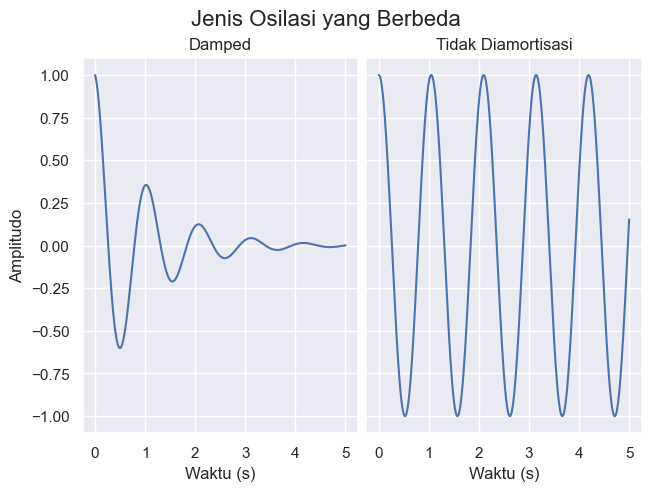

In [56]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.0, 5.0, 501)
fig, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', sharey=True)

ax1.plot(x, np.cos(6*x) * np.exp(-x))
ax1.set_title('Damped')
ax1.set_xlabel('Waktu (s)')
ax1.set_ylabel('Amplitudo')

ax2.plot(x, np.cos(6*x))
ax2.set_xlabel('Waktu (s)')
ax2.set_title('Tidak Diamortisasi')

fig.suptitle('Jenis Osilasi yang Berbeda', fontsize=16)

plt.show()
